In [210]:
import numpy as np
import pandas as pd
from pathlib import Path
from build_moex_curve import build_moex_curve
from factor_analysis import run_factor_analysis, run_pca
from var import run_var
from excess_returns import compute_excess_returns
from short_rate import run_short_rate, fit_short_rate
from market_price_of_risk import run_market_price_of_risk, fit_market_price_of_risk
from risk_neutral_curve import run_risk_neutral_curve
from term_premium import run_term_premium
from ruonia import load_ruonia_1m, build_ruonia_monthly
import  matplotlib.dates as mdates

In [211]:
K_FACTOR = 1.6
A2 = 0.6
CLEAN_DIR = Path('.')
DEFAULT_DYNAMIC_PATH = CLEAN_DIR/ "data" / "dynamic.csv"
DEFAULT_DAILY_OUTPUT = CLEAN_DIR / "output" / "moex_curve_daily.csv"
DEFAULT_MONTHLY_OUTPUT = CLEAN_DIR / "output" / "moex_curve_monthly.csv"
months =  tuple(range(12, 181, 12))
all_months = tuple(range(1, 181, 1))
excluded_all_months = tuple(range(3, 181, 1))
FACTOR_COLUMNS = ["PC1", "PC2", "PC3"]


In [212]:
def build_month_end_curve_from_daily(all_daily_curve: pd.DataFrame) -> pd.DataFrame:
    curve_cols = [c for c in all_daily_curve.columns if c.startswith("M")]
    out = all_daily_curve.copy()
    out["tradedate"] = pd.to_datetime(out["tradedate"])
    out = out.sort_values(["tradedate", "datetime"]).reset_index(drop=True)

    pt_curve = (
        out.groupby(out["tradedate"].dt.to_period("M"), as_index=False)
        .tail(1)
        .copy()
    )

    pt_curve["month_end"] = pt_curve["tradedate"].dt.to_period("M").dt.to_timestamp("M")
    pt_curve["month"] = pt_curve["month_end"].dt.to_period("M").astype(str)

    return pt_curve[["month", "month_end", *curve_cols]].reset_index(drop=True)

def make_short_rate_df_from_curve_m001(curve_df: pd.DataFrame) -> pd.DataFrame:
    if "M001" not in curve_df.columns:
        raise ValueError("curve_df must contain column 'M001'")
    sr = curve_df[["month", "month_end", "M001"]].copy()
    sr["month_end"] = pd.to_datetime(sr["month_end"])
    sr["ruonia_1m_pct"] = pd.to_numeric(sr["M001"], errors="coerce")
    sr["short_rate_monthly_cc"] = np.log1p(sr["ruonia_1m_pct"] / 100.0) / 12.0
    sr = sr.dropna(subset=["short_rate_monthly_cc"]).reset_index(drop=True)
    return sr[["month", "month_end", "ruonia_1m_pct", "short_rate_monthly_cc"]]

In [213]:
daily_curve, monthly_curve = build_moex_curve(
        dynamic_path=DEFAULT_DYNAMIC_PATH,
        daily_output_path=DEFAULT_DAILY_OUTPUT,
        monthly_output_path=DEFAULT_MONTHLY_OUTPUT,
        months=months,
    )
all_daily_curve, all_monthly_curve = build_moex_curve(
        dynamic_path=DEFAULT_DYNAMIC_PATH,
        daily_output_path=DEFAULT_DAILY_OUTPUT,
        monthly_output_path=DEFAULT_MONTHLY_OUTPUT,
        months=all_months,
    )
excluded_daily_curve, excluded_month_curve = build_moex_curve(
        dynamic_path=DEFAULT_DYNAMIC_PATH,
        daily_output_path=DEFAULT_DAILY_OUTPUT,
        monthly_output_path=DEFAULT_MONTHLY_OUTPUT,
        months=excluded_all_months,
    )
date_to_date_curve = build_month_end_curve_from_daily(all_daily_curve)

In [214]:
curve_m_cut = all_monthly_curve.iloc[:, 4:].copy()
curve_m_cut['month_end'] = all_monthly_curve['month_end']
curve_m_cut['month'] = all_monthly_curve['month']

In [215]:
scores, loadings, summary = run_pca(curve_m_cut, 3) 

# loadings = pd.read_csv('lib_loadings.csv')
# loadings.rename(columns={'maturity_months':'tenor', "PC 1" : "PC1", "PC 2" : "PC2", "PC 3" : "PC3"}, inplace=True)
# scores = (
#     pd.read_csv('lib_scores.csv', parse_dates=['date'])
#     .rename(columns={"PC 1": "PC1", "PC 2": "PC2", "PC 3": "PC3"})
#     .reset_index()
#     .rename(columns={"date": "month_end"})
# )

# scores["month_end"] = pd.to_datetime(scores["month_end"])
# scores["month"] = scores["month_end"].dt.to_period("M").astype(str)

# scores = scores[["month", "month_end", "PC1", "PC2", "PC3"]].copy()
scores

,month,month_end,PC1,PC2,PC3
0,2014-01,2014-01-31,-7.471088,1.343869,-0.037492
1,2014-02,2014-02-28,-6.609111,1.198114,0.282040
2,2014-03,2014-03-31,-3.227505,0.986604,0.540497
3,2014-04,2014-04-30,-3.380700,1.088962,0.276536
4,2014-05,2014-05-31,-3.417655,0.322282,0.235133
...,...,...,...,...,...
142,2025-11,2025-11-30,15.859851,1.794940,1.008513
143,2025-12,2025-12-31,15.590518,1.219876,0.654601
144,2026-01,2026-01-31,16.438008,1.524773,0.602247
145,2026-02,2026-02-28,16.562299,1.141284,0.494892


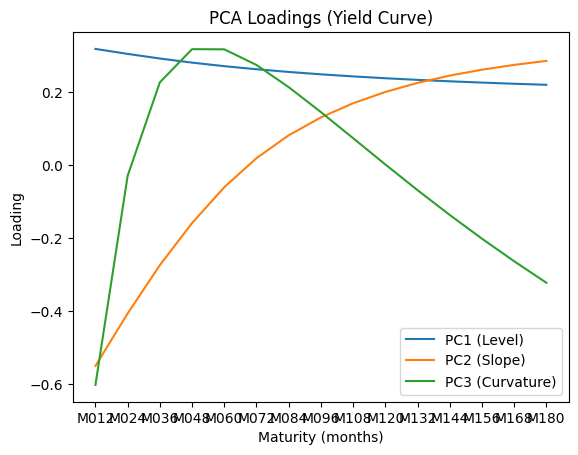

In [216]:
import matplotlib.pyplot as plt
tenors = loadings['tenor']

plt.figure()
plt.plot(tenors, loadings['PC1'])
plt.plot(tenors, loadings['PC2'])
plt.plot(tenors, loadings['PC3'])

plt.xlabel('Maturity (months)')
plt.ylabel('Loading')
plt.title('PCA Loadings (Yield Curve)')
plt.legend(['PC1 (Level)', 'PC2 (Slope)', 'PC3 (Curvature)'])
plt.show()

In [217]:
summary

,component,explained_variance,explained_variance_ratio,cumulative_explained_variance_ratio,n_tenors,yield_space
0,PC1,114.525768,0.982332,0.982332,15,continuous_pct
1,PC2,1.830212,0.015698,0.998031,15,continuous_pct
2,PC3,0.214800,0.001842,0.999873,15,continuous_pct


In [218]:
# plt.figure()
# plt.plot(scores['month_end'], scores['PC1'])
# plt.plot(scores['month_end'], scores['PC2'])
# plt.plot(scores['month_end'], scores['PC3'])

# plt.xlabel('Time')
# plt.ylabel('Factor value')
# plt.title('PCA Factors over Time')
# plt.legend(['PC1', 'PC2', 'PC3'])
# plt.show()

In [219]:
# params_df, residuals_df, fitted_df, summary_df = run_var(scores)
import numpy as np
import pandas as pd

from var import selected_factor_columns


factor_columns = selected_factor_columns(scores)
x = scores[factor_columns].to_numpy(dtype=float)

# ACM / pyacm-style VAR(1):
# 1. estimate VAR with intercept
# 2. keep phi
# 3. force mu = 0
rhs_full = np.column_stack([np.ones(len(x) - 1), x[:-1]])
coef_full, _, _, _ = np.linalg.lstsq(rhs_full, x[1:], rcond=None)

phi = coef_full[1:].T
mu = np.zeros(len(factor_columns), dtype=float)

fitted_next = x[:-1] @ phi.T
residuals = x[1:] - fitted_next

params_rows = []
for row_idx, equation in enumerate(factor_columns):
    params_rows.append(
        {
            "equation": equation,
            "term": "const",
            "value": 0.0,
        }
    )
    for col_idx, source in enumerate(factor_columns):
        params_rows.append(
            {
                "equation": equation,
                "term": f"lag1_{source}",
                "value": float(phi[row_idx, col_idx]),
            }
        )

params_df = pd.DataFrame(params_rows)

fitted_df = scores.iloc[1:][["month", "month_end"]].copy()
for idx, column in enumerate(factor_columns):
    fitted_df[column] = fitted_next[:, idx]

residuals_df = scores.iloc[1:][["month", "month_end"]].copy()
for idx, column in enumerate(factor_columns):
    residuals_df[f"eps_{column}"] = residuals[:, idx]

sigma = np.cov(residuals, rowvar=False, bias=False)
eigvals = np.linalg.eigvals(phi)
residual_norm = np.linalg.norm(residuals, axis=1)

summary_df = pd.DataFrame(
    [
        {
            "n_obs": len(scores),
            "n_equations": len(factor_columns),
            "spectral_radius": float(np.max(np.abs(eigvals))),
            "residual_mean_norm": float(residual_norm.mean()),
            "residual_std_norm": float(residual_norm.std(ddof=0)),
            "sigma_trace": float(np.trace(sigma)),
        }
    ]
)

display(params_df.head(12))
display(residuals_df.head())
display(summary_df)


,equation,term,value
0,PC1,const,0.000000
1,PC1,lag1_PC1,0.985354
2,PC1,lag1_PC2,0.187815
3,PC1,lag1_PC3,0.310946
4,PC2,const,0.000000
5,PC2,lag1_PC1,0.001108
6,PC2,lag1_PC2,0.928584
7,PC2,lag1_PC3,-0.176949
8,PC3,const,0.000000
9,PC3,lag1_PC1,-0.000739


,month,month_end,eps_PC1,eps_PC2,eps_PC3
1,2014-02,2014-02-28,0.511813,-0.048137,0.275727
2,2014-03,2014-03-31,2.972085,-0.068716,0.268927
3,2014-04,2014-04-30,-0.553830,0.272035,-0.205348
4,2014-05,2014-05-31,-0.376981,-0.636232,-0.026777
5,2014-06,2014-06-30,-1.582040,-0.449192,-0.182300


,n_obs,n_equations,spectral_radius,residual_mean_norm,residual_std_norm,sigma_trace
0,147,3,0.989119,1.508098,1.628522,4.934738


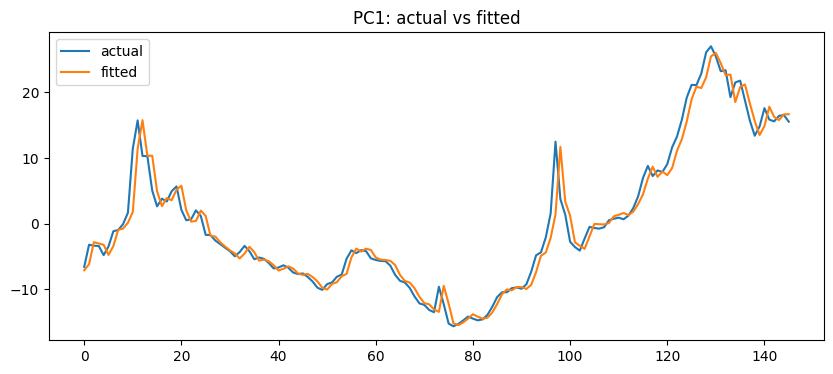

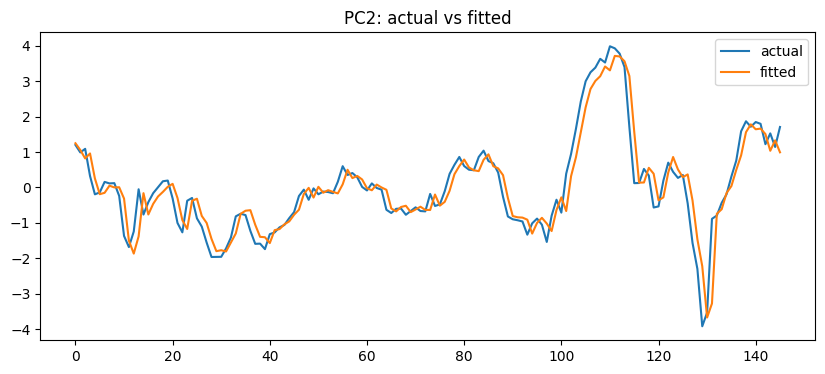

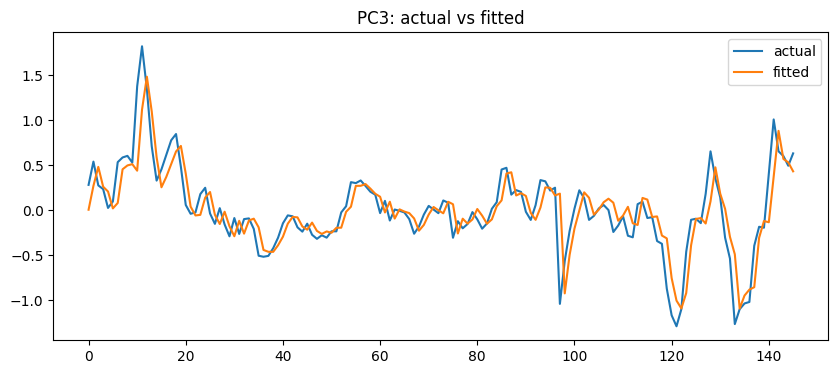

In [220]:
import matplotlib.pyplot as plt

fitted = fitted_df
actual = scores.iloc[1:][FACTOR_COLUMNS]

for col in FACTOR_COLUMNS:
    plt.figure(figsize=(10, 4))
    plt.plot(actual[col].values, label="actual")
    plt.plot(fitted[col].values, label="fitted")
    plt.title(f"{col}: actual vs fitted")
    plt.legend()
    plt.show()

In [221]:
import numpy as np

for col in FACTOR_COLUMNS:
    y = actual[col].values
    y_hat = fitted[col].values

    ss_res = np.sum((y - y_hat)**2)
    ss_tot = np.sum((y - y.mean())**2)

    r2 = 1 - ss_res / ss_tot

    print(f"{col}: R² = {r2:.4f}")

PC1: R² = 0.9596
PC2: R² = 0.8635
PC3: R² = 0.7059


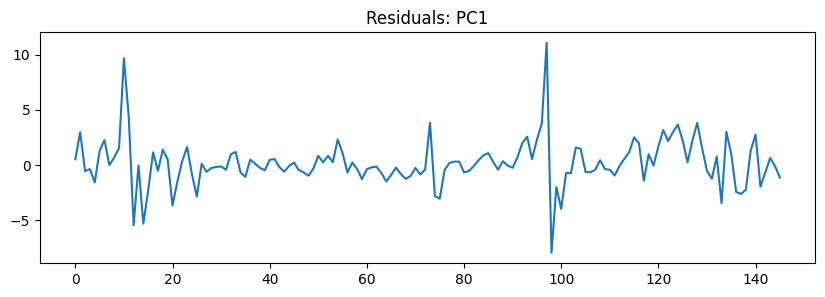

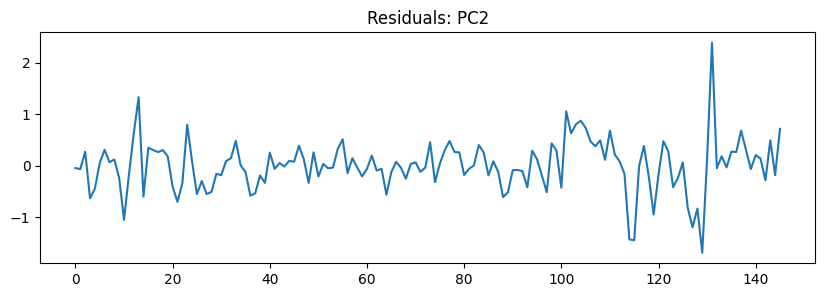

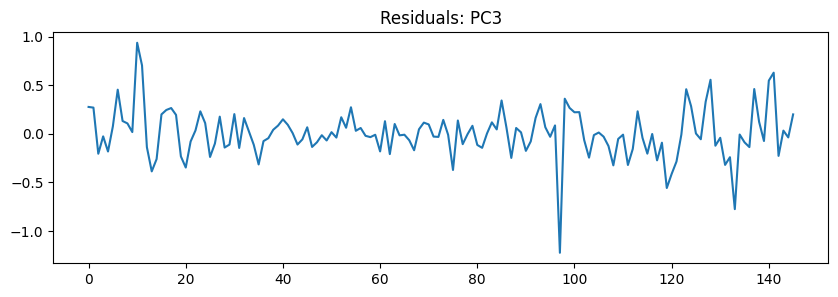

In [222]:
for col in FACTOR_COLUMNS:
    plt.figure(figsize=(10, 3))
    plt.plot(residuals_df[f"eps_{col}"].values)
    plt.title(f"Residuals: {col}")
    plt.show()

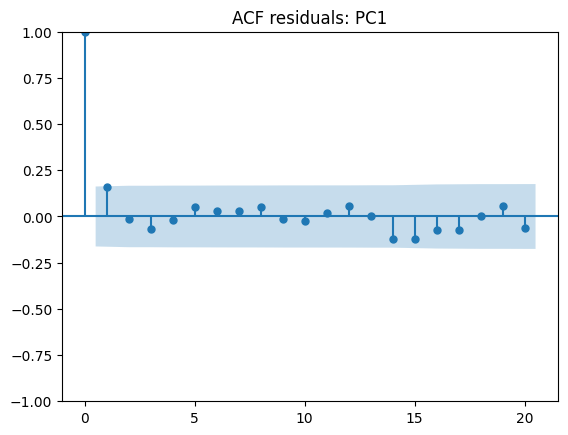

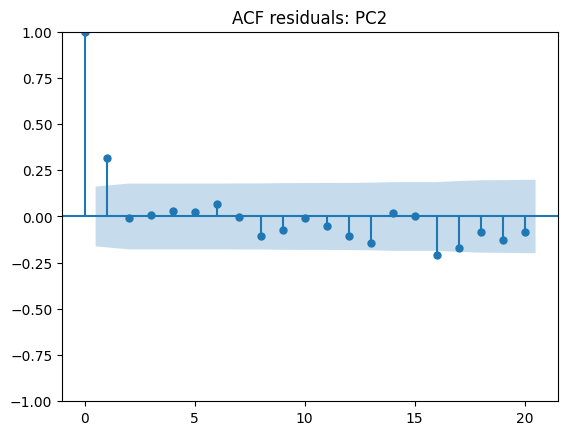

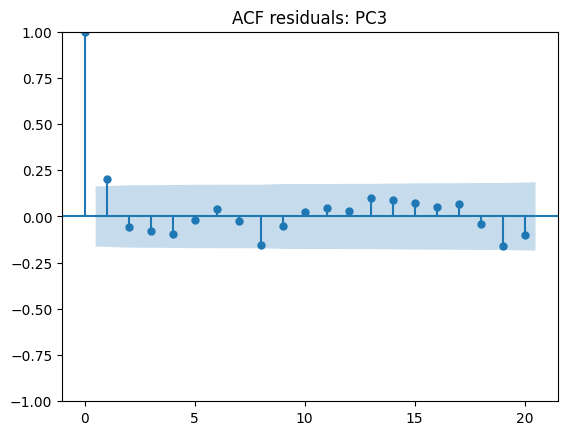

In [223]:
from statsmodels.graphics.tsaplots import plot_acf

for col in FACTOR_COLUMNS:
    plot_acf(residuals_df[f"eps_{col}"].values, lags=20)
    plt.title(f"ACF residuals: {col}")
    plt.show()

In [224]:
ruonia_raw = load_ruonia_1m('data/ruonia_1m.csv')
ruonia_monthly = build_ruonia_monthly(ruonia_raw)
short_from_curve = make_short_rate_df_from_curve_m001(all_monthly_curve)

holding_period_months = 1
curve_months = [int(col[1:]) for col in all_monthly_curve.columns if col.startswith("M")]
curve_months = sorted(curve_months)

pricing_months = [m for m in curve_months if m > holding_period_months]

available_months = list(range(min(curve_months), max(curve_months) + 1))

In [225]:
panel, summary = compute_excess_returns(
        curve_df=all_monthly_curve,
        short_rate_df=short_from_curve,
        available_months=available_months,
        pricing_months=pricing_months,
        holding_period_months=holding_period_months,
        use_all_pricing_tenors=False,
    )

In [226]:
panel

,start_month,start_month_end,end_month,end_month_end,rx_M002,rx_M003,rx_M004,rx_M005,rx_M006,rx_M007,...,rx_M171,rx_M172,rx_M173,rx_M174,rx_M175,rx_M176,rx_M177,rx_M178,rx_M179,rx_M180
0,2014-01,2014-01-31,2014-02,2014-02-28,0.000053,0.000074,0.000066,0.000031,-0.000030,-0.000113,...,-0.007709,-0.007571,-0.007433,-0.007295,-0.007156,-0.007017,-0.006877,-0.006737,-0.006596,-0.006455
1,2014-02,2014-02-28,2014-03,2014-03-31,-0.000311,-0.000731,-0.001250,-0.001858,-0.002544,-0.003300,...,-0.089748,-0.090089,-0.090430,-0.090771,-0.091112,-0.091453,-0.091794,-0.092136,-0.092477,-0.092819
2,2014-03,2014-03-31,2014-04,2014-04-30,0.000238,0.000425,0.000569,0.000677,0.000757,0.000816,...,-0.003016,-0.002988,-0.002958,-0.002926,-0.002891,-0.002854,-0.002815,-0.002775,-0.002732,-0.002687
3,2014-04,2014-04-30,2014-05,2014-05-31,-0.000071,-0.000261,-0.000525,-0.000828,-0.001147,-0.001464,...,0.031922,0.032130,0.032338,0.032545,0.032751,0.032956,0.033161,0.033365,0.033568,0.033771
4,2014-05,2014-05-31,2014-06,2014-06-30,-0.000272,-0.000411,-0.000441,-0.000383,-0.000253,-0.000065,...,0.058676,0.058918,0.059160,0.059401,0.059642,0.059883,0.060124,0.060364,0.060604,0.060844
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,2025-10,2025-10-31,2025-11,2025-11-30,0.001494,0.002819,0.003992,0.005032,0.005951,0.006763,...,0.079647,0.080401,0.081155,0.081911,0.082667,0.083423,0.084181,0.084939,0.085698,0.086457
142,2025-11,2025-11-30,2025-12,2025-12-31,-0.000573,-0.001070,-0.001494,-0.001850,-0.002142,-0.002375,...,0.023206,0.023377,0.023548,0.023719,0.023891,0.024064,0.024237,0.024411,0.024585,0.024759
143,2025-12,2025-12-31,2026-01,2026-01-31,0.000072,0.000132,0.000181,0.000219,0.000245,0.000260,...,-0.042935,-0.043322,-0.043710,-0.044098,-0.044486,-0.044875,-0.045263,-0.045652,-0.046041,-0.046430
144,2026-01,2026-01-31,2026-02,2026-02-28,-0.000322,-0.000615,-0.000880,-0.001115,-0.001322,-0.001502,...,0.008121,0.008153,0.008183,0.008214,0.008244,0.008274,0.008303,0.008332,0.008361,0.008389


,tenor_months,mean_bp,std_bp,neg_share
0,2,-5.905094,9.122712,0.767123
1,3,-6.203097,13.784946,0.712329
2,4,-6.497793,19.536792,0.698630
3,5,-6.789020,25.560050,0.636986
4,6,-7.077427,31.682134,0.630137
...,...,...,...,...
174,176,-51.656917,674.533799,0.513699
175,177,-51.865285,677.819791,0.513699
176,178,-52.073489,681.111862,0.513699
177,179,-52.281534,684.410110,0.513699


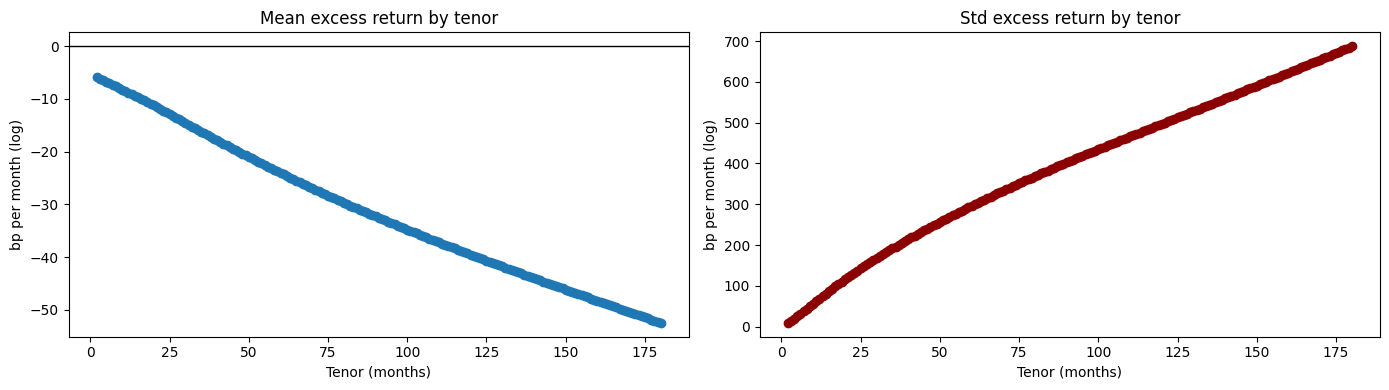

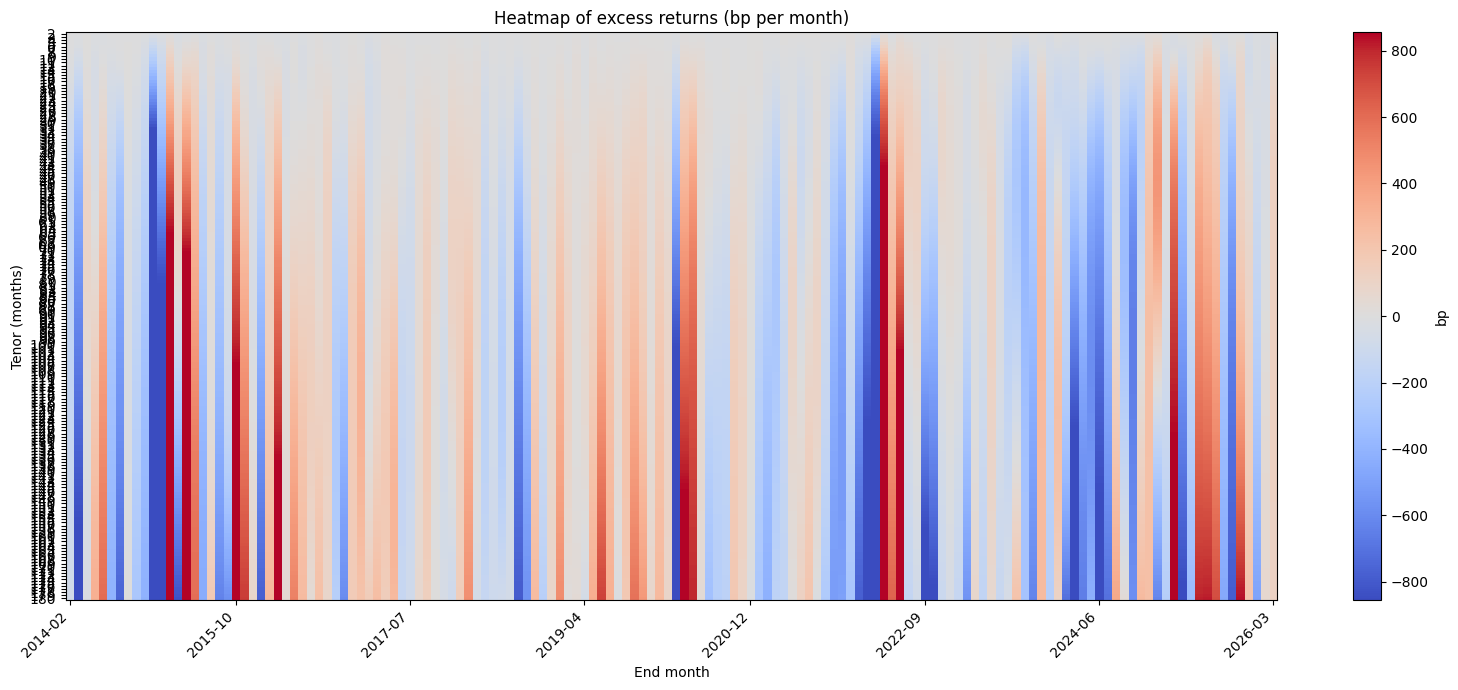

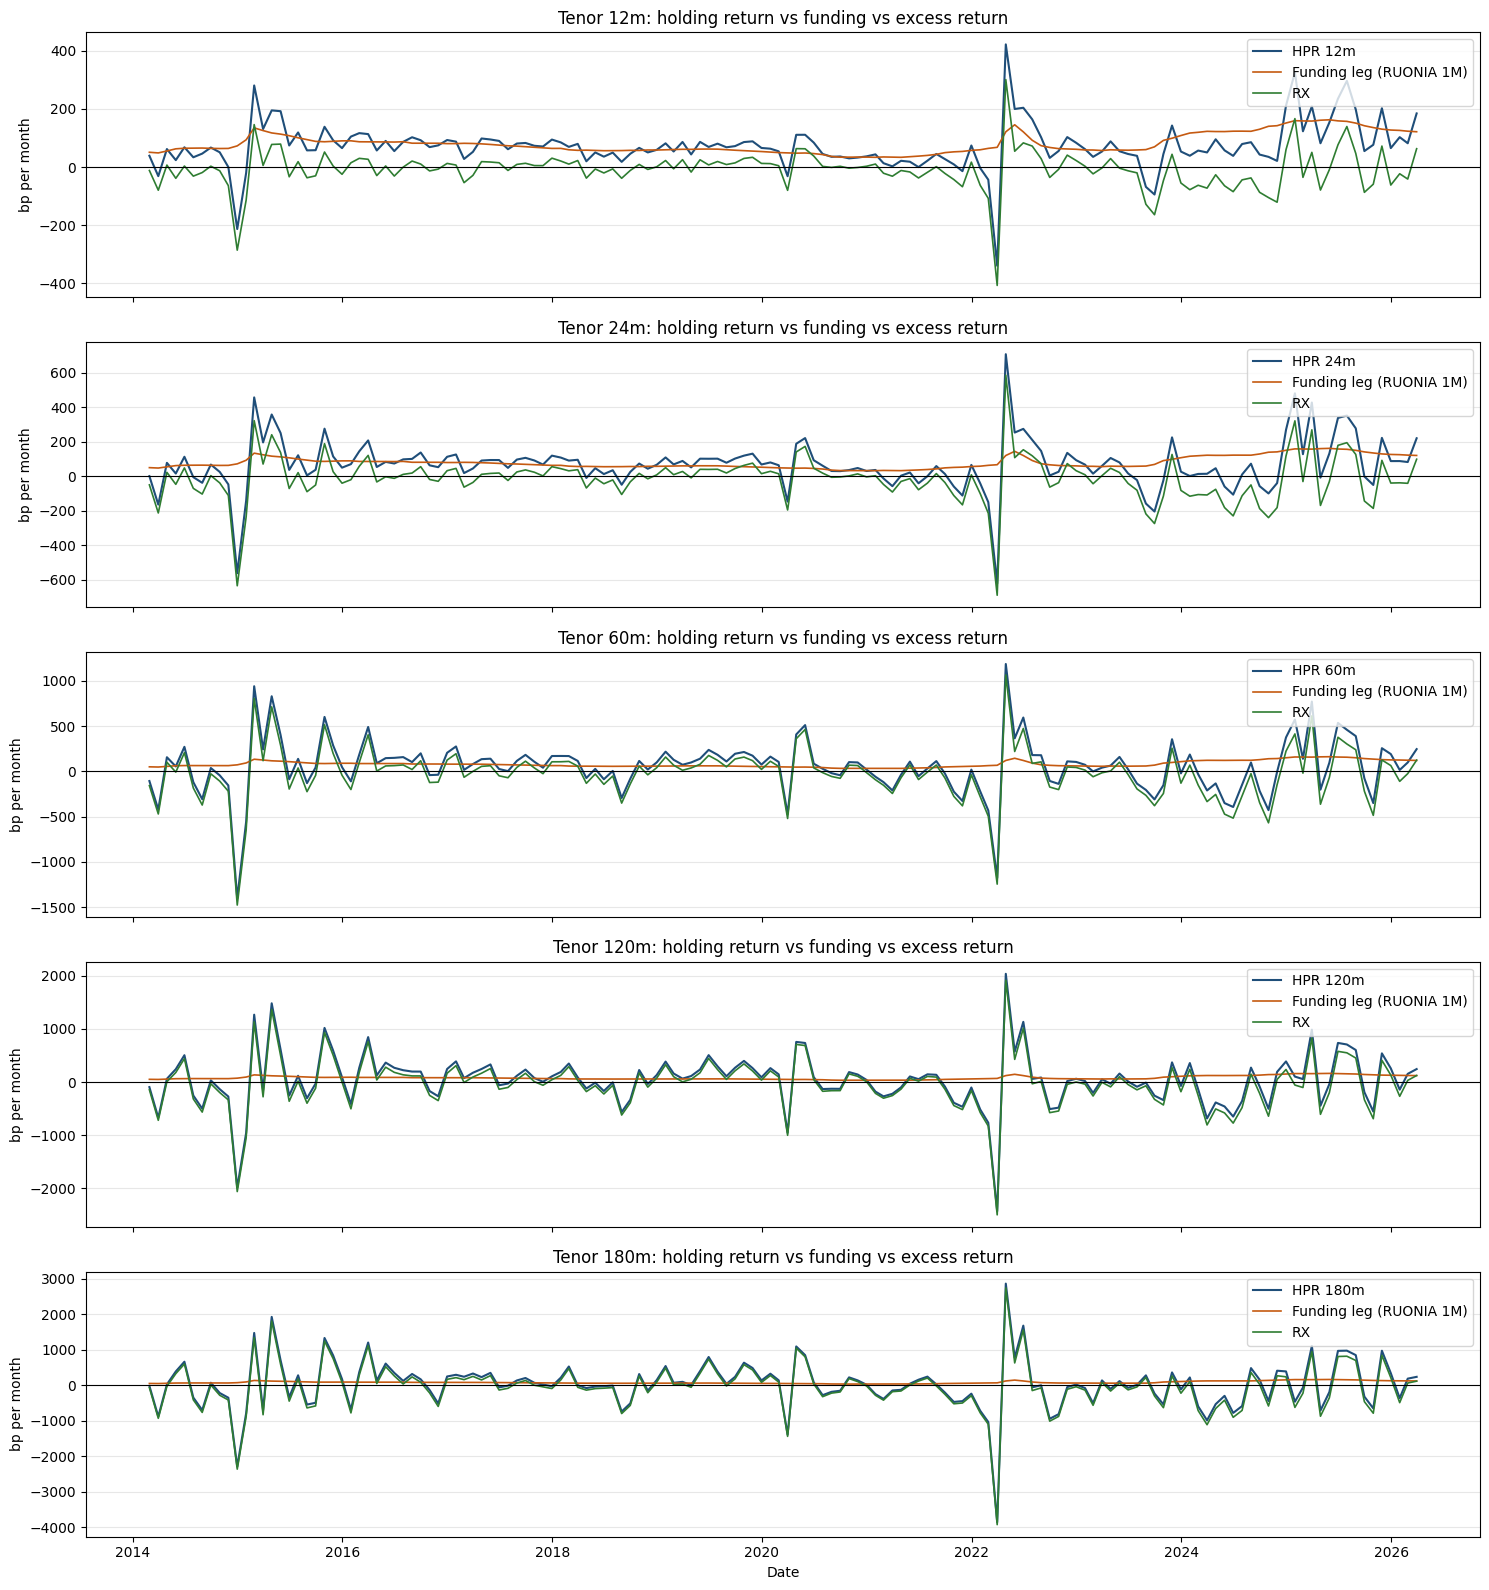

,t,t1,p_t_n_bp,p_t1_nminus1_bp,funding_bp,hpr_bp,rx_bp
134,2025-03-31,2025-04-30,-7095.164430,-7296.855358,161.061917,-201.690928,-362.752845
135,2025-04-30,2025-05-31,-7415.519467,-7318.755570,162.506790,96.763897,-65.742893
136,2025-05-31,2025-06-30,-7438.801064,-6902.352871,158.816162,536.448193,377.632032
137,2025-06-30,2025-07-31,-7018.694236,-6558.345995,157.079614,460.348241,303.268627
138,2025-07-31,2025-08-31,-6671.106703,-6280.713230,151.125847,390.393474,239.267627
139,2025-08-31,2025-09-30,-6390.463183,-6467.451997,142.028701,-76.988813,-219.017514
140,2025-09-30,2025-10-31,-6579.036551,-6929.075453,135.707303,-350.038902,-485.746205
141,2025-10-31,2025-11-30,-7046.672012,-6789.969438,130.280932,256.702574,126.421642
142,2025-11-30,2025-12-31,-6905.181420,-6713.213478,127.236863,191.967942,64.731079
143,2025-12-31,2026-01-31,-6826.253572,-6810.165459,125.989644,16.088112,-109.901532


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from excess_returns import build_log_price_matrix, build_funding_leg

curve_df = all_monthly_curve.copy()
short_rate_df = ruonia_monthly.copy()

holding_period_months = 1

curve_months = sorted(int(c[1:]) for c in curve_df.columns if c.startswith("M"))
pricing_months = [m for m in curve_months if m > holding_period_months]

# merge curve with RUONIA 1M monthly
curve_rx = curve_df.merge(
    short_rate_df[["month", "month_end", "ruonia_1m_pct", "short_rate_monthly_cc"]],
    on=["month", "month_end"],
    how="inner",
).sort_values("month_end").reset_index(drop=True)

y_columns = [f"M{m:03d}" for m in curve_months]
yields_cc = np.log1p(curve_rx[y_columns].to_numpy(dtype=float) / 100.0)
log_prices = build_log_price_matrix(yields_cc=yields_cc, months=curve_months)

funding_leg = build_funding_leg(
    short_rate_monthly_cc=curve_rx["short_rate_monthly_cc"].to_numpy(dtype=float),
    holding_period_months=holding_period_months,
)

month_to_idx = {m: i for i, m in enumerate(curve_months)}

rx_arrays = {}
diag = pd.DataFrame({
    "start_month_end": curve_rx["month_end"].iloc[:-holding_period_months].to_numpy(),
    "end_month_end": curve_rx["month_end"].iloc[holding_period_months:].to_numpy(),
    "funding_bp": funding_leg * 10000.0,
})

for m in pricing_months:
    start_idx = month_to_idx[m]
    end_idx = month_to_idx[m - holding_period_months]

    hpr = log_prices[holding_period_months:, end_idx] - log_prices[:-holding_period_months, start_idx]
    rx = hpr - funding_leg

    rx_arrays[f"rx_M{m:03d}"] = rx

# selected tenors for decomposition charts
selected_tenors = [12, 24, 60, 120, 180]
selected_tenors = [m for m in selected_tenors if m in pricing_months]

for m in selected_tenors:
    start_idx = month_to_idx[m]
    end_idx = month_to_idx[m - holding_period_months]

    hpr = log_prices[holding_period_months:, end_idx] - log_prices[:-holding_period_months, start_idx]
    rx = hpr - funding_leg

    diag[f"hpr_M{m:03d}_bp"] = hpr * 10000.0
    diag[f"rx_M{m:03d}_bp"] = rx * 10000.0

rx_panel_full = pd.concat(
    [
        pd.DataFrame({
            "start_month": curve_rx["month"].iloc[:-holding_period_months].to_numpy(),
            "start_month_end": curve_rx["month_end"].iloc[:-holding_period_months].to_numpy(),
            "end_month": curve_rx["month"].iloc[holding_period_months:].to_numpy(),
            "end_month_end": curve_rx["month_end"].iloc[holding_period_months:].to_numpy(),
        }),
        pd.DataFrame(rx_arrays),
    ],
    axis=1,
)

rx_cols = [c for c in rx_panel_full.columns if c.startswith("rx_M")]

diag_summary = pd.DataFrame({
    "tenor_months": [int(c.replace("rx_M", "")) for c in rx_cols],
    "mean_bp": (rx_panel_full[rx_cols].mean() * 10000.0).to_numpy(),
    "std_bp": (rx_panel_full[rx_cols].std(ddof=0) * 10000.0).to_numpy(),
    "neg_share": (rx_panel_full[rx_cols] < 0).mean().to_numpy(),
}).sort_values("tenor_months")

display(diag_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(diag_summary["tenor_months"], diag_summary["mean_bp"], marker="o")
axes[0].axhline(0.0, color="black", lw=1)
axes[0].set_title("Mean excess return by tenor")
axes[0].set_xlabel("Tenor (months)")
axes[0].set_ylabel("bp per month (log)")

axes[1].plot(diag_summary["tenor_months"], diag_summary["std_bp"], marker="o", color="darkred")
axes[1].set_title("Std excess return by tenor")
axes[1].set_xlabel("Tenor (months)")
axes[1].set_ylabel("bp per month (log)")

plt.tight_layout()
plt.show()

rx_matrix = rx_panel_full[rx_cols].to_numpy(dtype=float).T * 10000.0
rx_tenors = [int(c.replace("rx_M", "")) for c in rx_cols]

cap = np.nanpercentile(np.abs(rx_matrix), 95)

fig, ax = plt.subplots(figsize=(16, 7))
im = ax.imshow(
    rx_matrix,
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
    vmin=-cap,
    vmax=cap,
)

ax.set_title("Heatmap of excess returns (bp per month)")
ax.set_yticks(np.arange(len(rx_tenors)))
ax.set_yticklabels(rx_tenors)
ax.set_ylabel("Tenor (months)")

xtick_idx = np.linspace(0, len(rx_panel_full) - 1, 8, dtype=int)
xtick_labels = pd.to_datetime(rx_panel_full["end_month_end"]).dt.strftime("%Y-%m").iloc[xtick_idx]
ax.set_xticks(xtick_idx)
ax.set_xticklabels(xtick_labels, rotation=45, ha="right")
ax.set_xlabel("End month")

plt.colorbar(im, ax=ax, label="bp")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(selected_tenors), 1, figsize=(15, 3.2 * len(selected_tenors)), sharex=True)

if len(selected_tenors) == 1:
    axes = [axes]

for ax, m in zip(axes, selected_tenors):
    ax.plot(diag["end_month_end"], diag[f"hpr_M{m:03d}_bp"], label=f"HPR {m}m", color="#1f4e79", lw=1.5)
    ax.plot(diag["end_month_end"], diag["funding_bp"], label="Funding leg (RUONIA 1M)", color="#c55a11", lw=1.2)
    ax.plot(diag["end_month_end"], diag[f"rx_M{m:03d}_bp"], label="RX", color="#2f7d32", lw=1.2)
    ax.axhline(0.0, color="black", lw=0.8)
    ax.set_title(f"Tenor {m}m: holding return vs funding vs excess return")
    ax.set_ylabel("bp per month")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(loc="upper right")

axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

check_tenor = 60
tmp = pd.DataFrame({
    "t": curve_rx["month_end"].iloc[:-1].to_numpy(),
    "t1": curve_rx["month_end"].iloc[1:].to_numpy(),
    "p_t_n_bp": log_prices[:-1, month_to_idx[check_tenor]] * 10000.0,
    "p_t1_nminus1_bp": log_prices[1:, month_to_idx[check_tenor - 1]] * 10000.0,
    "funding_bp": funding_leg * 10000.0,
})
tmp["hpr_bp"] = tmp["p_t1_nminus1_bp"] - tmp["p_t_n_bp"]
tmp["rx_bp"] = tmp["hpr_bp"] - tmp["funding_bp"]

display(tmp.tail(12))


,tenor_months,mean_log_bp,mean_simple_bp,std_log_bp,neg_share
0,12,-8.794627,-8.555436,68.715893,0.520548
1,24,-12.556401,-11.608535,137.415282,0.506849
2,60,-24.035427,-19.657432,296.303692,0.500000
3,120,-39.527384,-27.240490,497.330233,0.493151
4,180,-52.489428,-29.145801,687.714632,0.513699


,sample,tenor_months,mean_log_bp,mean_simple_bp,std_log_bp,neg_share,n_obs
0,2014-2019,12,-3.204997,-3.086051,48.773386,0.422535,71
1,2014-2019,24,-0.868675,-0.265042,110.334848,0.422535,71
2,2014-2019,60,5.436590,9.270579,278.919998,0.394366,71
3,2014-2019,120,18.895016,29.006713,451.740483,0.394366,71
4,2014-2019,180,33.789010,50.486421,577.996746,0.422535,71
5,2020-2021,12,-5.986266,-5.930008,33.014506,0.541667,24
6,2020-2021,24,-14.102992,-13.786598,78.343861,0.541667,24
7,2020-2021,60,-33.127850,-31.061821,200.848542,0.625000,24
8,2020-2021,120,-57.341259,-51.304792,343.871105,0.500000,24
9,2020-2021,180,-81.265522,-70.636141,456.290164,0.583333,24


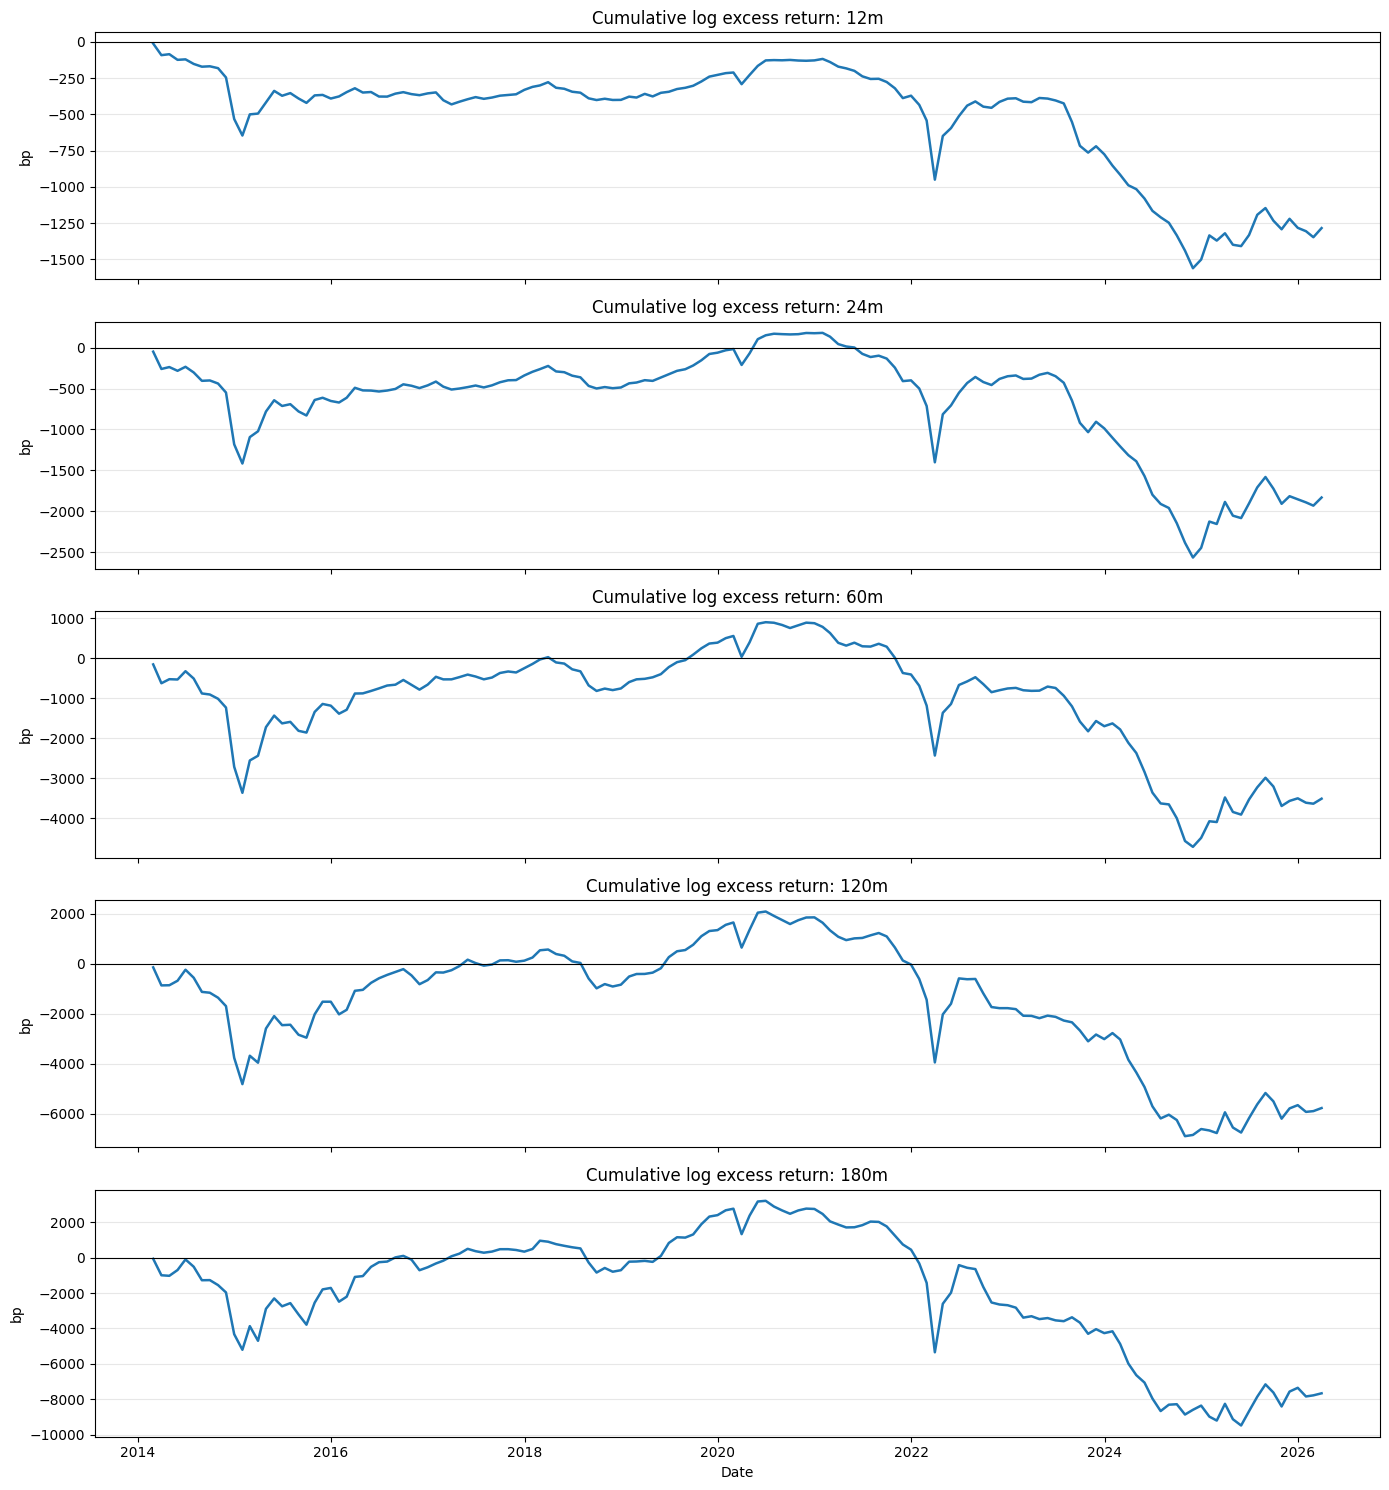

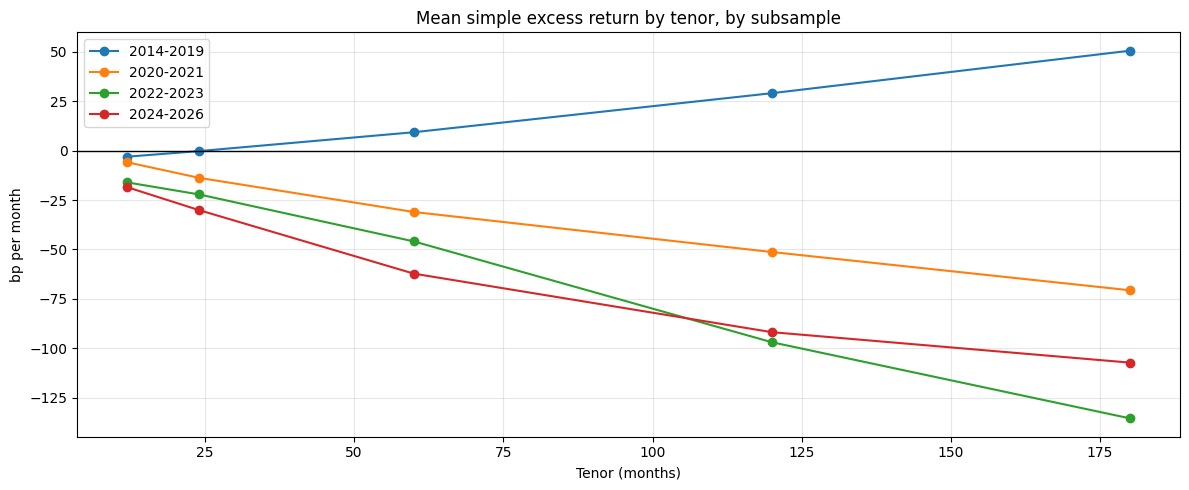

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# use the rx panel you already built on full curve
df = rx_panel_full.copy()

selected_tenors = [12, 24, 60, 120, 180]
selected_tenors = [m for m in selected_tenors if f"rx_M{m:03d}" in df.columns]

full_sample = pd.DataFrame({
    "tenor_months": selected_tenors,
    "mean_log_bp": [df[f"rx_M{m:03d}"].mean() * 10000 for m in selected_tenors],
    "mean_simple_bp": [(np.exp(df[f"rx_M{m:03d}"]) - 1).mean() * 10000 for m in selected_tenors],
    "std_log_bp": [df[f"rx_M{m:03d}"].std(ddof=0) * 10000 for m in selected_tenors],
    "neg_share": [(df[f"rx_M{m:03d}"] < 0).mean() for m in selected_tenors],
})
display(full_sample)

subsamples = {
    "2014-2019": ("2014-01-01", "2019-12-31"),
    "2020-2021": ("2020-01-01", "2021-12-31"),
    "2022-2023": ("2022-01-01", "2023-12-31"),
    "2024-2026": ("2024-01-01", "2026-12-31"),
}

rows = []
for label, (start, end) in subsamples.items():
    mask = (df["end_month_end"] >= pd.Timestamp(start)) & (df["end_month_end"] <= pd.Timestamp(end))
    tmp = df.loc[mask]
    for m in selected_tenors:
        col = f"rx_M{m:03d}"
        rows.append({
            "sample": label,
            "tenor_months": m,
            "mean_log_bp": tmp[col].mean() * 10000,
            "mean_simple_bp": (np.exp(tmp[col]) - 1).mean() * 10000,
            "std_log_bp": tmp[col].std(ddof=0) * 10000,
            "neg_share": (tmp[col] < 0).mean(),
            "n_obs": len(tmp),
        })

subsample_table = pd.DataFrame(rows)
display(subsample_table)

fig, axes = plt.subplots(len(selected_tenors), 1, figsize=(14, 3 * len(selected_tenors)), sharex=True)

if len(selected_tenors) == 1:
    axes = [axes]

for ax, m in zip(axes, selected_tenors):
    col = f"rx_M{m:03d}"
    cum_log_bp = df[col].cumsum() * 10000
    ax.plot(df["end_month_end"], cum_log_bp, lw=1.8)
    ax.axhline(0.0, color="black", lw=0.8)
    ax.set_title(f"Cumulative log excess return: {m}m")
    ax.set_ylabel("bp")
    ax.grid(True, axis="y", alpha=0.3)

axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))

for label in subsamples:
    tmp = subsample_table[subsample_table["sample"] == label]
    ax.plot(tmp["tenor_months"], tmp["mean_simple_bp"], marker="o", label=label)

ax.axhline(0.0, color="black", lw=1)
ax.set_title("Mean simple excess return by tenor, by subsample")
ax.set_xlabel("Tenor (months)")
ax.set_ylabel("bp per month")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [229]:
panel['rx_M120'].mean(),panel['rx_M060'].mean(), panel['rx_M024'].mean(), 

(np.float64(-0.003392195356638157),
 np.float64(-0.0018429995943248351),
 np.float64(-0.0006950970375950812))

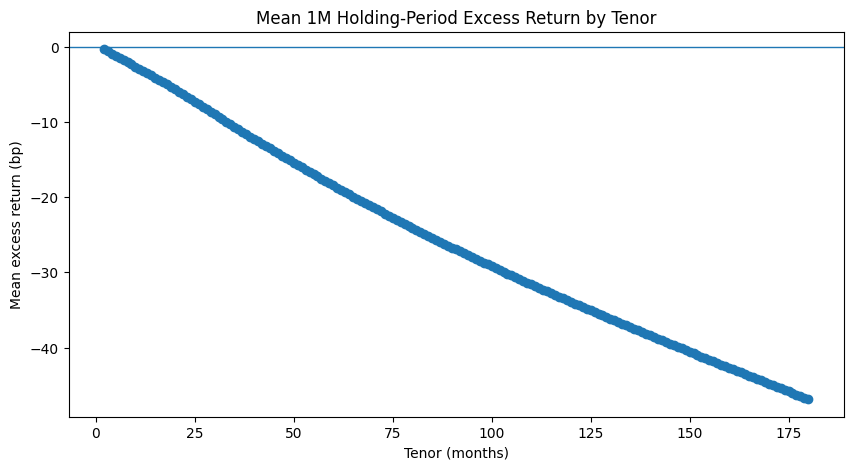

In [230]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(summary["tenor_months"], summary["mean_bp"], marker="o")
plt.axhline(0.0, linewidth=1)
plt.xlabel("Tenor (months)")
plt.ylabel("Mean excess return (bp)")
plt.title("Mean 1M Holding-Period Excess Return by Tenor")
plt.show()

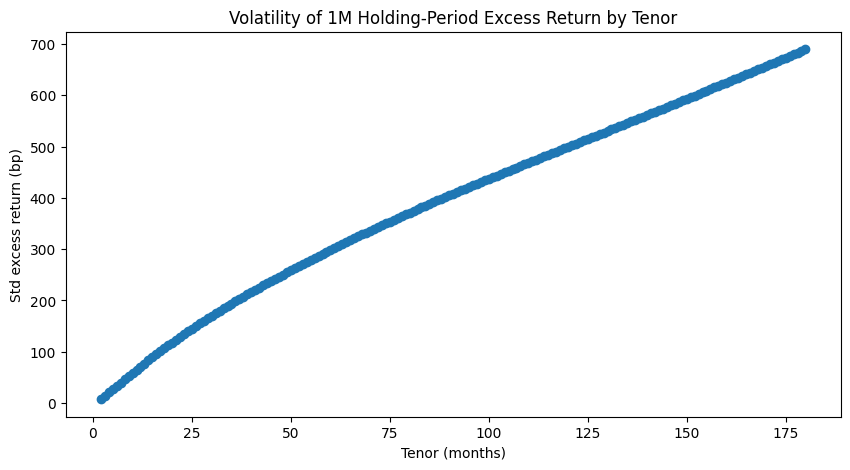

In [231]:
plt.figure(figsize=(10, 5))
plt.plot(summary["tenor_months"], summary["std_bp"], marker="o")
plt.xlabel("Tenor (months)")
plt.ylabel("Std excess return (bp)")
plt.title("Volatility of 1M Holding-Period Excess Return by Tenor")
plt.show()

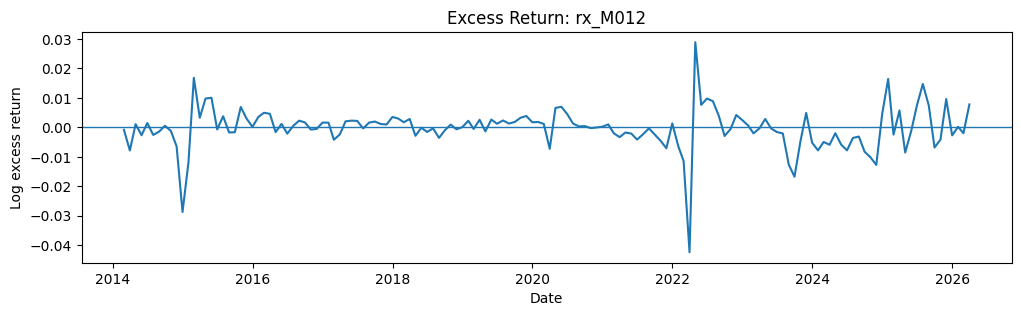

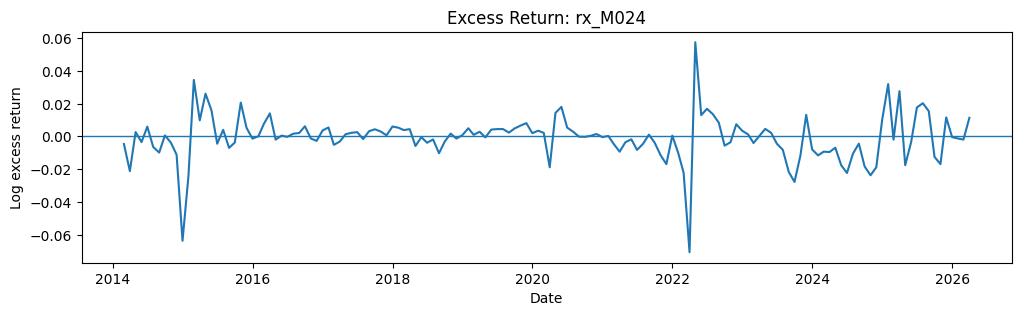

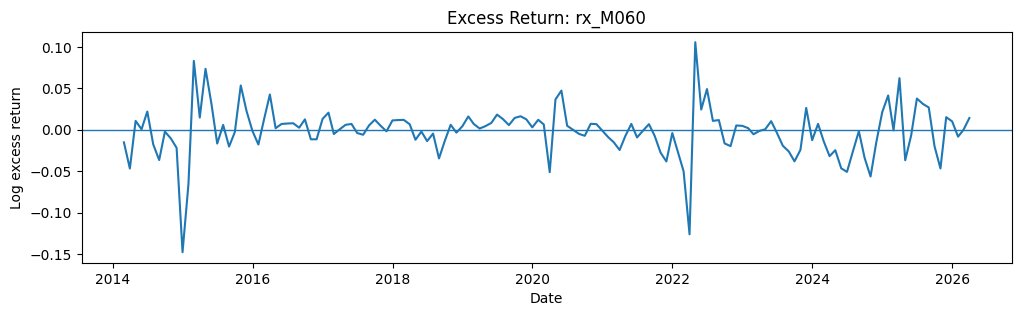

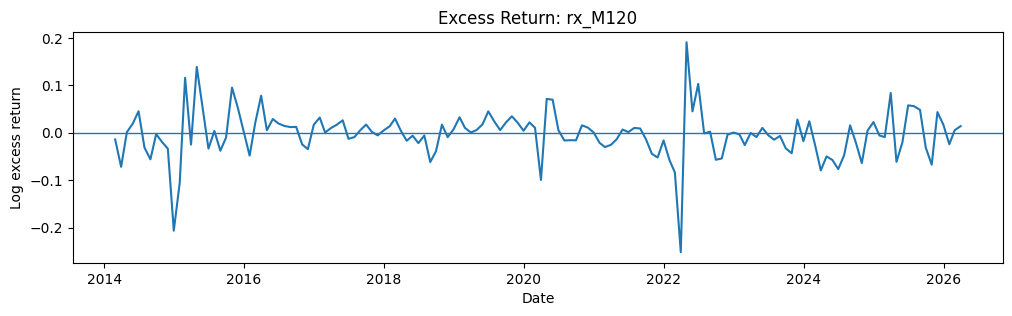

In [232]:
rx_cols = ["rx_M012", "rx_M024", "rx_M060", "rx_M120", "rx_M240", "rx_M360"]
rx_cols = [c for c in rx_cols if c in panel.columns]

for col in rx_cols:
    plt.figure(figsize=(12, 3))
    plt.plot(panel["end_month_end"], panel[col])
    plt.axhline(0.0, linewidth=1)
    plt.title(f"Excess Return: {col}")
    plt.xlabel("Date")
    plt.ylabel("Log excess return")
    plt.show()

In [233]:
short_rate_params_df, short_rate_fitted_df, short_rate_residuals_df, short_rate_summary_df = fit_short_rate(
        factors_df=scores,
        short_rate_df=short_from_curve,
    )
sigma2 = float(
    short_rate_params_df.loc[
        short_rate_params_df["parameter"] == "sigma2",
        "value",
    ].iloc[0]
)

In [234]:
(
    lambda_params,
    rx_regression_params,
    rx_fitted,
    rx_residuals,
    lambda_summary,
) = fit_market_price_of_risk(
    factors_df=scores,
    var_residuals_df=residuals_df,
    excess_returns_df=panel,
    sigma2=sigma2
)

# lambda_params['lambda0_PC3'] = 0.05324482
lambda_params

,parameter,value
0,lambda0_PC1,-0.064434
1,lambda0_PC2,-0.007117
2,lambda0_PC3,0.005711
3,omega_scalar,0.000003
4,lambda1_PC1_PC1,-0.008695
5,lambda1_PC1_PC2,0.140935
6,lambda1_PC1_PC3,0.146902
7,lambda1_PC2_PC1,0.000218
8,lambda1_PC2_PC2,-0.064543
9,lambda1_PC2_PC3,-0.007921


In [235]:
risk_neutral_df, risk_neutral_summary = run_risk_neutral_curve(
    curve_df=all_monthly_curve,
    factors_df=scores,
    var_params_df=params_df,
    var_residuals_df=residuals_df,
    short_rate_params_df=short_rate_params_df,
    lambda_params_df=lambda_params,
)
term_premium_df, term_premium_selected_df, term_premium_summary = run_term_premium(
    curve_df=all_monthly_curve,
    risk_neutral_df=risk_neutral_df,
)

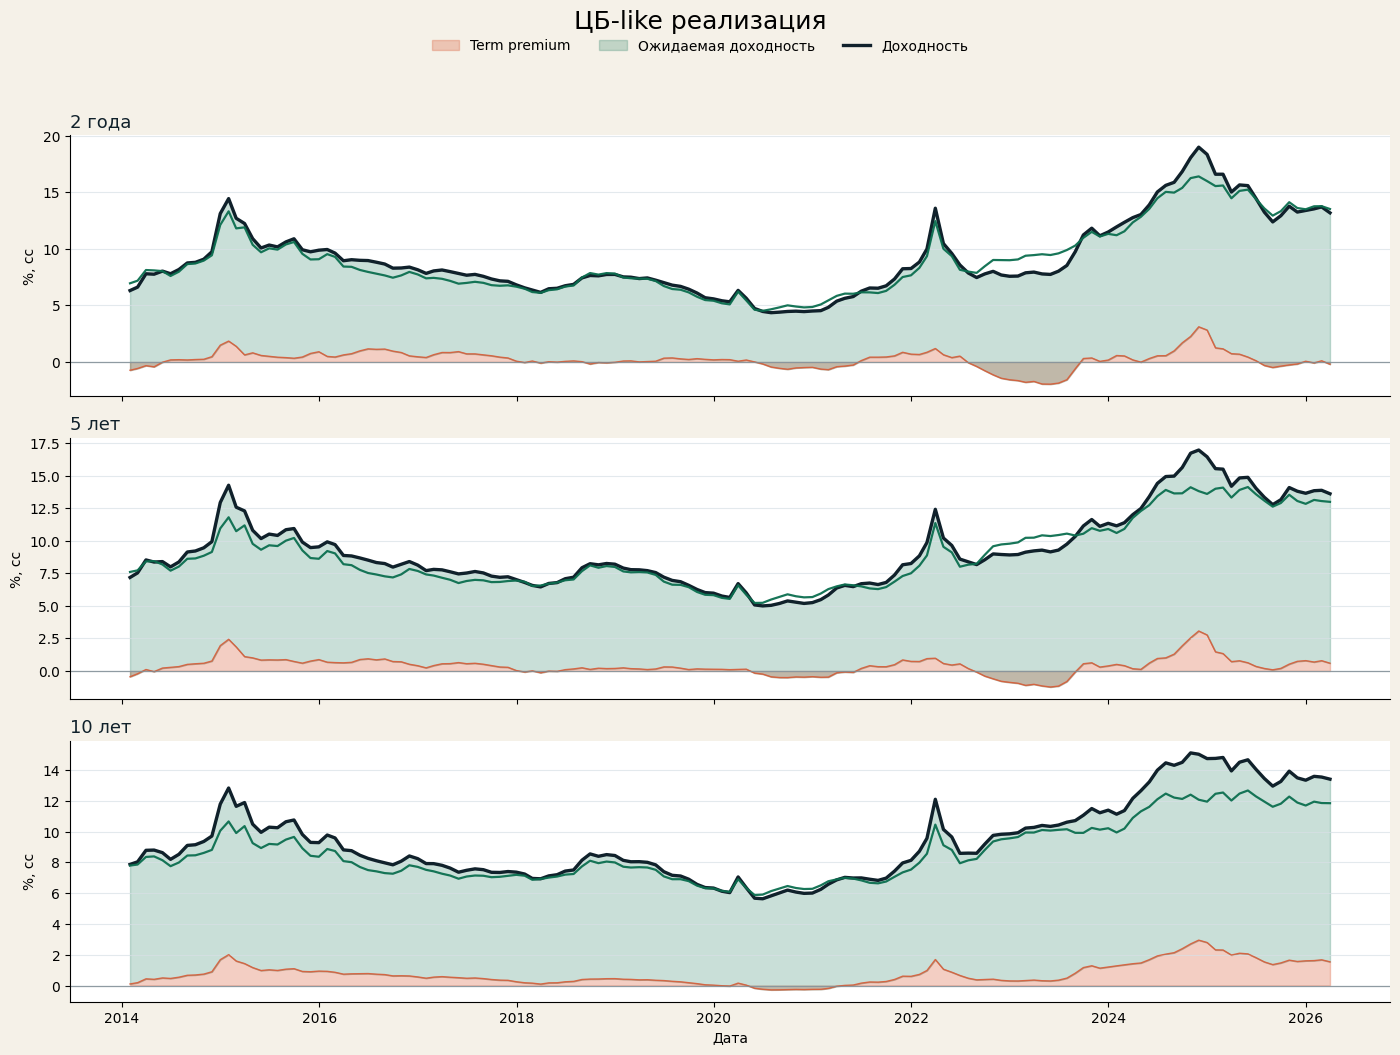

In [236]:
df = term_premium_df

tenors = {
    24: "2 года",
    60: "5 лет",
    120: "10 лет",
}

COLORS = {
    "obs": "#10212b",
    "rn": "#0b6e4f",
    "tp": "#d95d39",
    "bg": "#f5f1e8",
    "grid": "#d8e0e6",
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(15, 11),
    sharex=True,
    facecolor=COLORS["bg"],
)

dates = df["month_end"]

for ax, (month, label) in zip(axes, tenors.items()):
    obs = df[f"obs_M{month:03d}"]
    rn = df[f"rn_M{month:03d}"] 
    tp = df[f"tp_M{month:03d}"] 

    ax.set_facecolor("white")

    ax.fill_between(
        dates,
        0.0,
        tp,
        color=COLORS["tp"],
        alpha=0.30,
        label="Term premium",
        interpolate=True,
    )
    ax.fill_between(
        dates,
        tp,
        obs,
        color=COLORS["rn"],
        alpha=0.22,
        label="Ожидаемая доходность",
        interpolate=True,
    )

    ax.plot(dates, obs, color=COLORS["obs"], lw=2.4, label="Доходность")
    ax.plot(dates, rn, color=COLORS["rn"], lw=1.6, alpha=0.95)
    ax.plot(dates, tp, color=COLORS["tp"], lw=1.0, alpha=0.9)

    ax.axhline(0.0, color="#7a8890", lw=0.9, alpha=0.8)
    ax.set_title(label, loc="left", fontsize=13, color=COLORS["obs"])
    ax.set_ylabel("%, cc")
    ax.grid(True, axis="y", color=COLORS["grid"], alpha=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlabel("Дата")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.98))

fig.suptitle("ЦБ-like реализация", fontsize=18, y=0.995)
fig.tight_layout(rect=(0.03, 0.04, 0.97, 0.95))
plt.show()
